In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Semua library berhasil diimport")

In [5]:
# =============================
# CELL 2 - Load & Gabungkan Data Pernikahan
# =============================
import pandas as pd
import numpy as np

# Load semua file pernikahan per tahun
nikah_files = {
    2018: '../data/Nikah dan Cerai Menurut Provinsi, 2018.csv',
    2019: '../data/Nikah dan Cerai Menurut Provinsi, 2019.csv',
    2020: '../data/Nikah dan Cerai Menurut Provinsi, 2020.csv',
    2021: '../data/Nikah dan Cerai Menurut Provinsi, 2021.csv',
    2022: '../data/Nikah dan Cerai Menurut Provinsi, 2022.csv',
    2023: '../data/Nikah dan Cerai Menurut Provinsi, 2023.csv',
    2024: '../data/Nikah dan Cerai Menurut Provinsi (kejadian), 2024.csv',
}

dfs = []
for tahun, path in nikah_files.items():
    df_temp = pd.read_csv(path)
    df_temp['tahun'] = tahun
    dfs.append(df_temp)

df_nikah = pd.concat(dfs, ignore_index=True)
df_nikah['Provinsi'] = df_nikah['Provinsi'].str.title().str.strip()
df_nikah['Nikah'] = pd.to_numeric(df_nikah['Nikah'], errors='coerce')

print(f"Total baris   : {df_nikah.shape[0]}")
print(f"Rentang tahun : {df_nikah['tahun'].min()} – {df_nikah['tahun'].max()}")
print(f"Jumlah provinsi: {df_nikah['Provinsi'].nunique()}")

# Load data fitur
df_ipm = pd.read_csv('../data/bps-od_15042_indeks_pmbngnn_manusia_menggunakan_uhh_sp2010_brds_v1_data.csv')
df_tpt = pd.read_csv('../data/bps-od_20206_tingkat_pengangguran_terbuka__prov_di_indonesia_data.csv')
df_miskin = pd.read_csv('../data/bps-od_20948_persentase_penduduk_miskin__prov_di_indonesia_v2_data.csv')

# Clean nama provinsi
for df_temp in [df_ipm, df_tpt, df_miskin]:
    df_temp['nama_provinsi'] = df_temp['nama_provinsi'].str.title().str.strip()

# Pilih kolom relevan
df_ipm = df_ipm[['nama_provinsi', 'tahun', 'indeks_pembangunan_manusia']]
df_tpt = df_tpt[['nama_provinsi', 'tahun', 'indeks_tpt']]
df_miskin = df_miskin[['nama_provinsi', 'tahun', 'persentase_penduduk_miskin']]

# Rename supaya konsisten
df_nikah.rename(columns={'Provinsi': 'nama_provinsi'}, inplace=True)

# Merge semua berdasarkan provinsi + tahun
df = df_nikah.merge(df_ipm, on=['nama_provinsi', 'tahun'], how='inner')
df = df.merge(df_tpt, on=['nama_provinsi', 'tahun'], how='inner')
df = df.merge(df_miskin, on=['nama_provinsi', 'tahun'], how='inner')

# Simpan dataset gabungan
df.to_csv('../data/dataset_gabungan.csv', index=False)

print(f"\nDataset gabungan selesai!")
print(f"Total baris   : {df.shape[0]}")
print(f"Total kolom   : {df.shape[1]}")
print(f"Kolom         : {list(df.columns)}")
df.head()

Total baris   : 282
Rentang tahun : 2018 – 2024
Jumlah provinsi: 55

Dataset gabungan selesai!
Total baris   : 242
Total kolom   : 9
Kolom         : ['nama_provinsi', 'Nikah', 'Cerai Talak', 'Cerai Gugat', 'Jumlah Cerai', 'tahun', 'indeks_pembangunan_manusia', 'indeks_tpt', 'persentase_penduduk_miskin']


,nama_provinsi,Nikah,Cerai Talak,Cerai Gugat,Jumlah Cerai,tahun,indeks_pembangunan_manusia,indeks_tpt,persentase_penduduk_miskin
0,Aceh,54399.0,1416,3714,5130,2018,71.19,6.34,15.97
1,Sumatera Utara,85989.0,3053,10714,13767,2018,71.18,5.55,9.22
2,Sumatera Barat,46053.0,2085,5412,7497,2018,71.73,5.66,6.65
3,Riau,45523.0,2945,7867,10812,2018,72.44,5.98,7.39
4,Jambi,28265.0,999,3184,4183,2018,70.65,3.73,7.92


In [6]:
# =============================
# CELL 3 - Eksplorasi Awal
# =============================
print("=== INFO DATASET ===")
print(df.info())
print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe().round(2))
print("\n=== CEK MISSING VALUES ===")
print(df.isnull().sum())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   nama_provinsi               242 non-null    object 
 1   Nikah                       242 non-null    float64
 2   Cerai Talak                 242 non-null    object 
 3   Cerai Gugat                 242 non-null    object 
 4   Jumlah Cerai                242 non-null    object 
 5   tahun                       242 non-null    int64  
 6   indeks_pembangunan_manusia  242 non-null    float64
 7   indeks_tpt                  242 non-null    float64
 8   persentase_penduduk_miskin  242 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 17.1+ KB
None

=== STATISTIK DESKRIPTIF ===
           Nikah    tahun  indeks_pembangunan_manusia  indeks_tpt  \
count     242.00   242.00                      242.00      242.00   
mean    5068

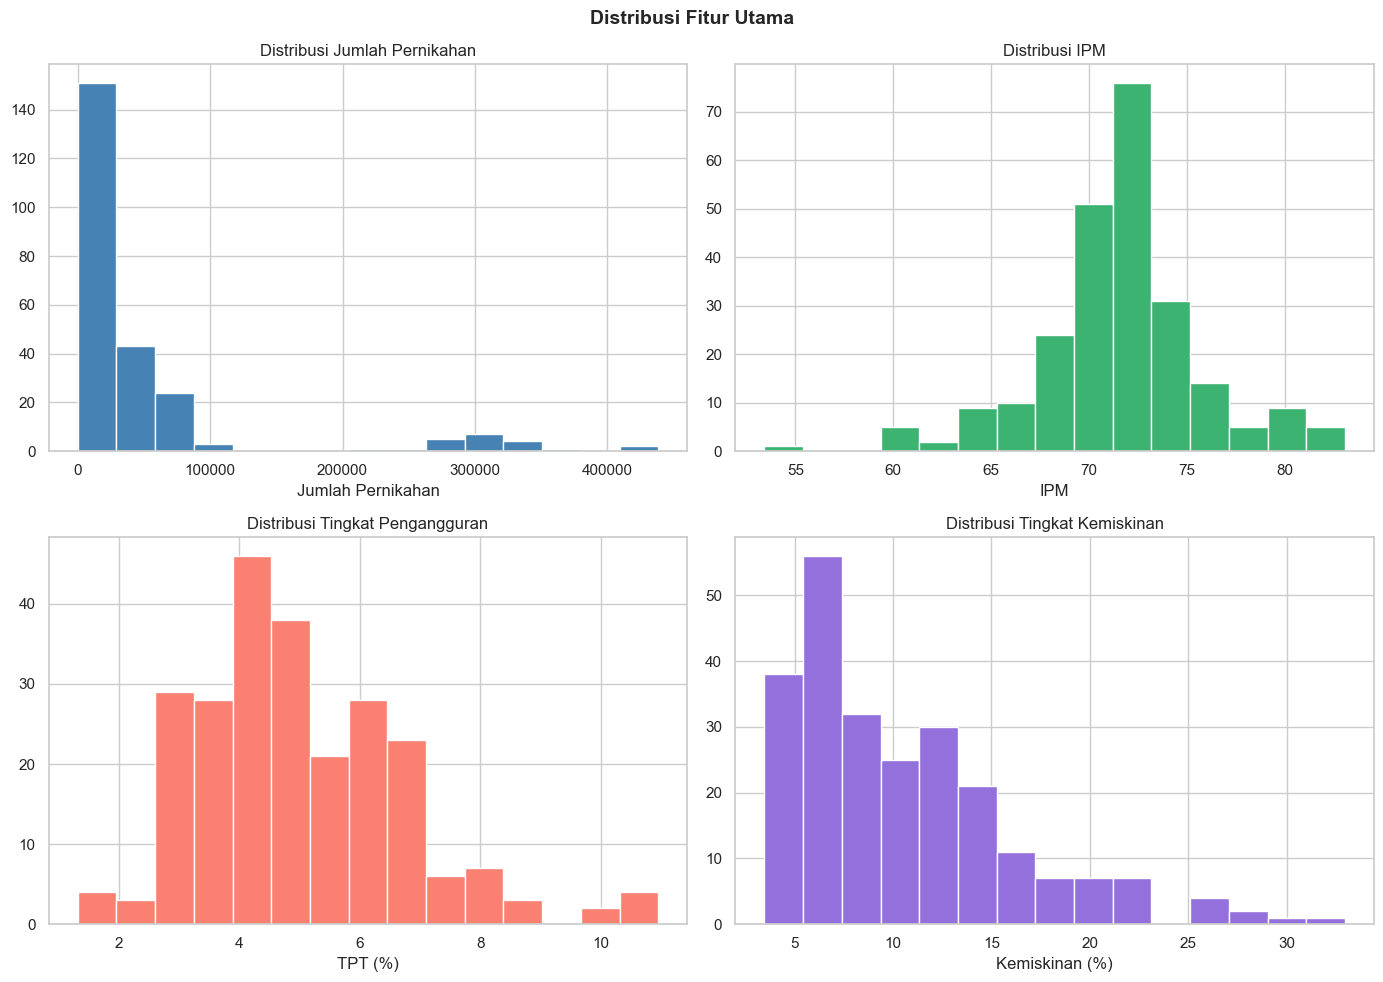

Visualisasi distribusi selesai!


In [12]:
# =============================
# CELL 4 - Visualisasi Distribusi
# =============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['Nikah'], bins=15, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribusi Jumlah Pernikahan')
axes[0,0].set_xlabel('Jumlah Pernikahan')

axes[0,1].hist(df['indeks_pembangunan_manusia'], bins=15, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribusi IPM')
axes[0,1].set_xlabel('IPM')

axes[1,0].hist(df['indeks_tpt'], bins=15, color='salmon', edgecolor='white')
axes[1,0].set_title('Distribusi Tingkat Pengangguran')
axes[1,0].set_xlabel('TPT (%)')

axes[1,1].hist(df['persentase_penduduk_miskin'], bins=15, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Distribusi Tingkat Kemiskinan')
axes[1,1].set_xlabel('Kemiskinan (%)')

plt.suptitle('Distribusi Fitur Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi distribusi selesai!")

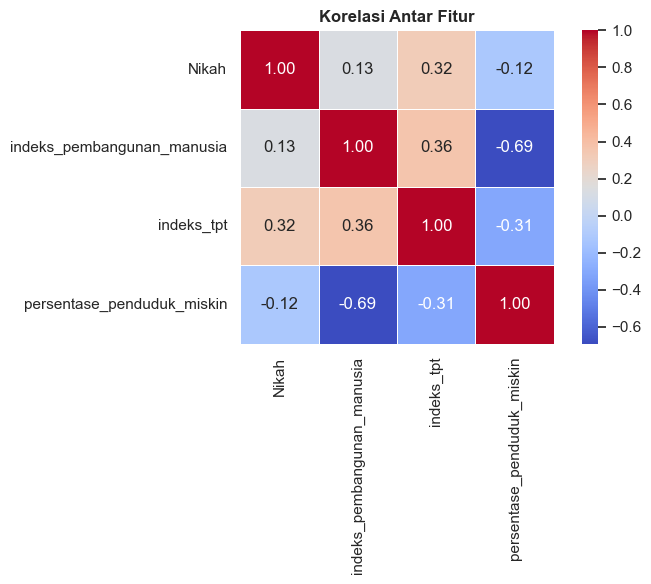

Heatmap korelasi selesai!


In [13]:
# =============================
# CELL 5 - Korelasi Antar Fitur
# =============================
corr = df[['Nikah', 'indeks_pembangunan_manusia', 'indeks_tpt', 'persentase_penduduk_miskin']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Korelasi Antar Fitur', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap korelasi selesai!")

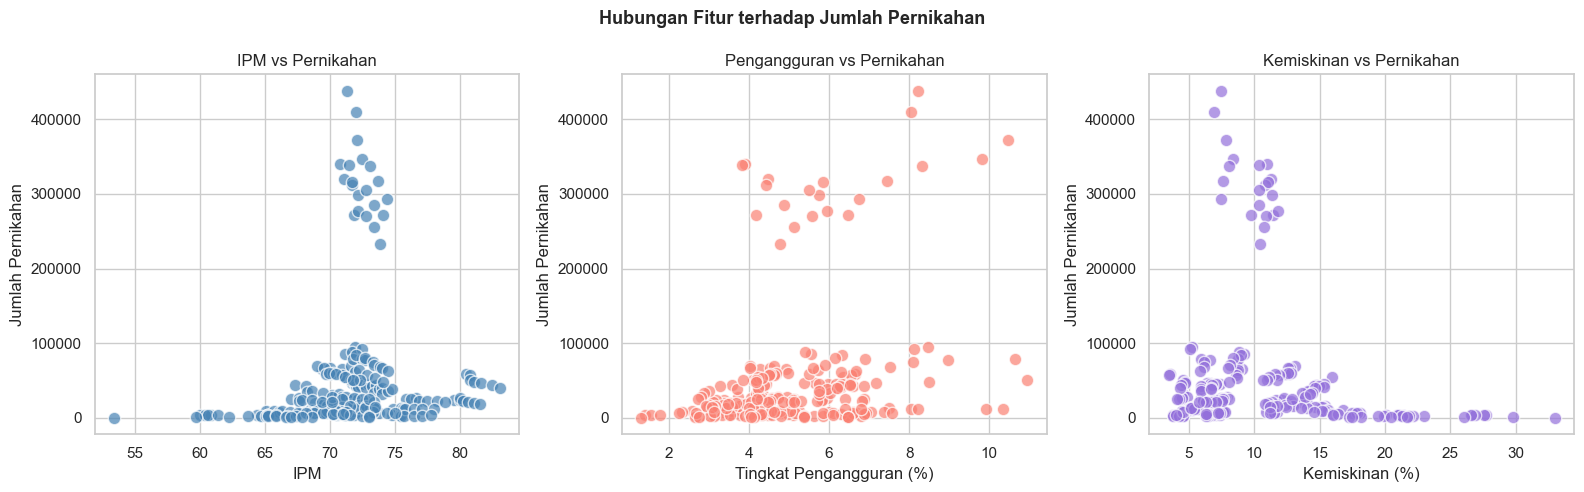

Scatter plot selesai!


In [14]:
# =============================
# CELL 6 - Scatter Plot
# =============================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['indeks_pembangunan_manusia'], df['Nikah'], color='steelblue', alpha=0.7, edgecolors='white', s=80)
axes[0].set_xlabel('IPM')
axes[0].set_ylabel('Jumlah Pernikahan')
axes[0].set_title('IPM vs Pernikahan')

axes[1].scatter(df['indeks_tpt'], df['Nikah'], color='salmon', alpha=0.7, edgecolors='white', s=80)
axes[1].set_xlabel('Tingkat Pengangguran (%)')
axes[1].set_ylabel('Jumlah Pernikahan')
axes[1].set_title('Pengangguran vs Pernikahan')

axes[2].scatter(df['persentase_penduduk_miskin'], df['Nikah'], color='mediumpurple', alpha=0.7, edgecolors='white', s=80)
axes[2].set_xlabel('Kemiskinan (%)')
axes[2].set_ylabel('Jumlah Pernikahan')
axes[2].set_title('Kemiskinan vs Pernikahan')

plt.suptitle('Hubungan Fitur terhadap Jumlah Pernikahan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot selesai!")

In [15]:
# =============================
# CELL 7 - Preprocessing
# =============================
features = ['indeks_pembangunan_manusia', 'indeks_tpt', 'persentase_penduduk_miskin']
target = 'Nikah'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai!")
print(f"Training set : {X_train.shape[0]} data")
print(f"Testing set  : {X_test.shape[0]} data")

Preprocessing selesai!
Training set : 193 data
Testing set  : 49 data


In [16]:
# =============================
# CELL 8 - Modeling
# =============================
import joblib

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Evaluasi
print("=== LINEAR REGRESSION ===")
print(f"R² Score : {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")

print("\n=== RANDOM FOREST ===")
print(f"R² Score : {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")

# Simpan model terbaik
joblib.dump(rf, '../models/rf_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("\nModel disimpan!")

=== LINEAR REGRESSION ===
R² Score : 0.1275
RMSE     : 93789.44

=== RANDOM FOREST ===
R² Score : 0.7561
RMSE     : 49585.49

Model disimpan!


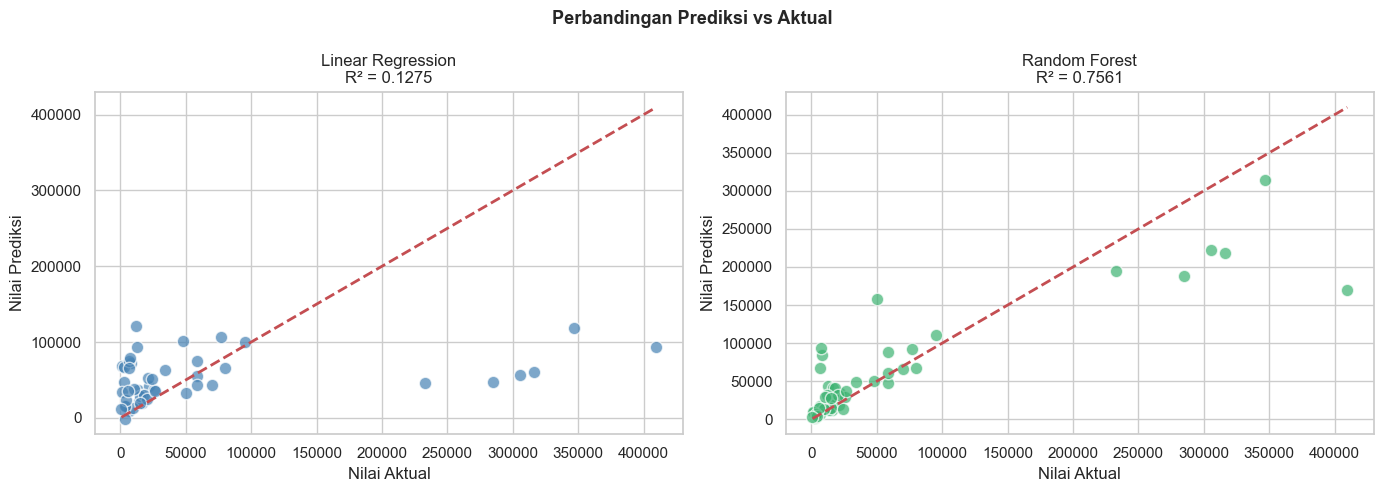

Visualisasi prediksi selesai!


In [17]:
# =============================
# CELL 9 - Visualisasi Prediksi
# =============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, color='steelblue', alpha=0.7, edgecolors='white', s=80)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title(f'Linear Regression\nR² = {r2_score(y_test, y_pred_lr):.4f}')

axes[1].scatter(y_test, y_pred_rf, color='mediumseagreen', alpha=0.7, edgecolors='white', s=80)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Nilai Aktual')
axes[1].set_ylabel('Nilai Prediksi')
axes[1].set_title(f'Random Forest\nR² = {r2_score(y_test, y_pred_rf):.4f}')

plt.suptitle('Perbandingan Prediksi vs Aktual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/prediksi_vs_aktual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi prediksi selesai!")

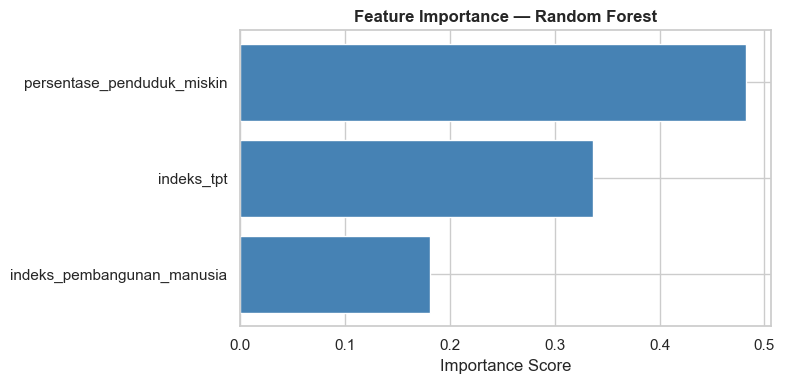

Feature importance selesai!

Fitur paling berpengaruh:
                     Fitur  Importance
persentase_penduduk_miskin    0.482127
                indeks_tpt    0.336484
indeks_pembangunan_manusia    0.181389


In [18]:
# =============================
# CELL 10 - Feature Importance
# =============================
importance = pd.DataFrame({
    'Fitur': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance['Fitur'], importance['Importance'], color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance selesai!")
print("\nFitur paling berpengaruh:")
print(importance.sort_values('Importance', ascending=False).to_string(index=False))

In [19]:
# =============================
# CELL 11 - Kesimpulan
# =============================
best_r2_lr = r2_score(y_test, y_pred_lr)
best_r2_rf = r2_score(y_test, y_pred_rf)
best_model = 'Random Forest' if best_r2_rf > best_r2_lr else 'Linear Regression'
best_r2 = max(best_r2_rf, best_r2_lr)

print("=== KESIMPULAN AKHIR ===\n")
print(f"Model terbaik : {best_model}")
print(f"R² Score      : {best_r2:.4f}")
print(f"\nInterpretasi:")
print(f"Model dapat menjelaskan {best_r2*100:.1f}% variasi jumlah pernikahan")
print(f"berdasarkan IPM, Tingkat Pengangguran, dan Kemiskinan per provinsi.")
print(f"\nFitur paling berpengaruh: {importance.iloc[-1]['Fitur']}")

=== KESIMPULAN AKHIR ===

Model terbaik : Random Forest
R² Score      : 0.7561

Interpretasi:
Model dapat menjelaskan 75.6% variasi jumlah pernikahan
berdasarkan IPM, Tingkat Pengangguran, dan Kemiskinan per provinsi.

Fitur paling berpengaruh: persentase_penduduk_miskin


=== PROVINSI ANOMALI ===
IPM tinggi + Kemiskinan rendah, tapi pernikahan RENDAH:
            nama_provinsi   Nikah  indeks_pembangunan_manusia  persentase_penduduk_miskin
                     Bali  3189.0                       77.76                        4.00
           Sulawesi Utara  6025.0                       75.03                        7.25
Kepulauan Bangka Belitung  7973.0                       73.33                        4.55
           Kepulauan Riau 11533.0                       77.97                        5.37


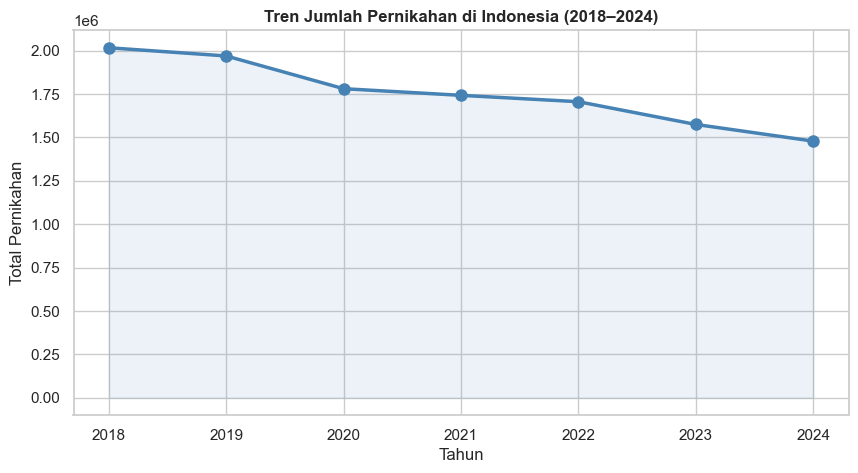


=== TREN NASIONAL ===
 tahun     Nikah
  2018 2016171.0
  2019 1968978.0
  2020 1780346.0
  2021 1742049.0
  2022 1705348.0
  2023 1574326.0
  2024 1478302.0


In [20]:
# =============================
# CELL 12 - Insight Menarik
# =============================
# Ambil data 2024 saja
df_2024 = df[df['tahun'] == 2024].copy()

# Normalisasi jumlah nikah per kapita (karena populasi tiap provinsi beda)
# Provinsi dengan IPM tinggi, kemiskinan rendah, tapi nikah rendah
df_2024['kategori'] = 'Normal'

ipm_median = df_2024['indeks_pembangunan_manusia'].median()
miskin_median = df_2024['persentase_penduduk_miskin'].median()
nikah_median = df_2024['Nikah'].median()

# Filter: IPM tinggi + kemiskinan rendah + pernikahan rendah
anomali = df_2024[
    (df_2024['indeks_pembangunan_manusia'] > ipm_median) &
    (df_2024['persentase_penduduk_miskin'] < miskin_median) &
    (df_2024['Nikah'] < nikah_median)
][['nama_provinsi', 'Nikah', 'indeks_pembangunan_manusia', 'persentase_penduduk_miskin']].sort_values('Nikah')

print("=== PROVINSI ANOMALI ===")
print("IPM tinggi + Kemiskinan rendah, tapi pernikahan RENDAH:")
print(anomali.to_string(index=False))

# Tren nasional per tahun
tren = df.groupby('tahun')['Nikah'].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(tren['tahun'], tren['Nikah'], marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(tren['tahun'], tren['Nikah'], alpha=0.1, color='steelblue')
plt.title('Tren Jumlah Pernikahan di Indonesia (2018–2024)', fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Total Pernikahan')
plt.xticks(tren['tahun'])
plt.savefig('../data/tren_pernikahan.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TREN NASIONAL ===")
print(tren.to_string(index=False))